# Detección de Fraude con Tarjetas de Crédito
## Análisis Exploratorio de Datos (EDA) con PySpark

**Objetivo.** Explorar el dataset público de fraude con tarjetas de crédito, identificar las señales que separan las transacciones fraudulentas de las legítimas y justificar, con evidencia, las decisiones de preprocesamiento y de manejo del desbalance de clases que alimentarán el pipeline de Machine Learning diseñado para **AWS Glue (PySpark)**.

**Dataset.** [Credit Card Fraud Detection (ULB, Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Según su documentación, contiene transacciones de tarjetas europeas realizadas durante dos días de septiembre de 2013: 284,807 registros, de los cuales 492 son fraudes. Las variables `V1`–`V28` son componentes principales (PCA) anonimizadas; `Time`, `Amount` y `Class` son las únicas variables sin transformar.

### Hallazgos principales

- El dataset no tiene valores nulos y presenta un desbalance extremo: 492 fraudes sobre 284,807 transacciones (0.173%).
- `Amount` tiene una cola derecha muy pesada. Sus valores atípicos se conservan (pueden ser señal) y se mitigan con `log1p` + `RobustScaler`.
- Los fraudes tienen una mediana de monto menor que las transacciones legítimas (9.25 vs 22.00), pero una mayor proporción de montos altos (18.9% vs 11.5% por encima del umbral IQR).
- Las componentes con mayor correlación con el fraude son `V17` (r = −0.33), `V14` (−0.30) y `V12` (−0.26).
- La tasa de fraude se dispara de madrugada: 1.71% a las 2 AM y 1.04% a las 4 AM, frente a un promedio global de 0.17%.
- `V14` y `V17` separan parcialmente ambas clases, pero no de forma lineal, lo que favorece a los modelos basados en árboles.
- **Decisión de arquitectura:** Cost-Sensitive Learning (`weightCol`) en lugar de SMOTE, evaluado con AUPRC.

### Contenido

1. Configuración e ingesta
2. Calidad de datos y variable objetivo
3. Valores atípicos en `Amount`
4. Correlación con la variable objetivo
5. Perfil estadístico por clase
6. Ingeniería de características: hora del día
7. Análisis bivariado: `V14` vs `V17`
8. Escalamiento de `Amount` y `Time`
9. Estrategia frente al desbalance de clases
10. Prueba empírica de estrategias
11. Conclusiones y próximos pasos

### Requisitos

Python 3.11 · Java 17 · `pyspark>=3.4` (se usa `F.median`) · `pandas` · `numpy` · `matplotlib` · `seaborn` · `scikit-learn`.
El archivo `creditcard.csv` (~145 MB) **no se incluye en el repositorio** por superar el límite de 100 MB de GitHub: descargarlo desde Kaggle y ubicarlo junto al notebook.

## 1. Configuración e ingesta

Se levanta una sesión local de Spark que emula el entorno de AWS Glue: la lógica de transformación es PySpark, por lo que se traslada a un clúster con cambios mínimos. En Glue, la principal diferencia sería la fuente de datos (una ruta `s3://...` en lugar de un archivo local).

In [1]:
import os
import pyspark

# Spark necesita un JDK (se recomienda 17). Si no lo detecta automáticamente,
# definir la variable de entorno JAVA_HOME en el sistema o descomentar y ajustar:
# os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17"
os.environ.setdefault("SPARK_HOME", os.path.dirname(pyspark.__file__))

from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CreditCardFraud_EDA")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")  # acelera toPandas()
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# En AWS Glue esta ruta apuntaría a S3 (p. ej. "s3://mi-bucket/creditcard.csv")
FILE_PATH = "creditcard.csv"

df = spark.read.csv(FILE_PATH, header=True, inferSchema=True)

print(f"Total de registros: {df.count():,} | Total de columnas: {len(df.columns)}")

Total de registros: 284,807 | Total de columnas: 31


## 2. Calidad de datos y variable objetivo

### 2.1 Valores nulos

En pandas se usaría `df.isnull().sum()`. En PySpark, la forma escalable es construir **una expresión de agregación por columna y ejecutarlas todas en una sola pasada**, lo que sigue siendo eficiente aunque el dataset pese terabytes en S3.

In [2]:
def count_nulls(dataframe):
    """Cuenta nulos y NaN por columna con una única pasada distribuida."""
    exprs = [
        F.count(F.when(F.col(c).isNull() | F.isnan(c), c)).alias(c)
        for c in dataframe.columns
    ]
    # El resultado es una sola fila, por lo que collect() es seguro
    count = dataframe.select(*exprs).collect()[0].asDict()
    with_nulls = {k: v for k, v in count.items() if v > 0}

    if not with_nulls:
        print("Sin valores nulos ni NaN en ninguna columna.")
    else:
        print("Columnas con valores faltantes:")
        for columna, n in with_nulls.items():
            print(f"- {columna}: {n:,}")
    return count


resumen_nulos = count_nulls(df)

Sin valores nulos ni NaN en ninguna columna.


El dataset no presenta valores faltantes, por lo que no se requiere imputación.

### 2.2 Distribución de la variable objetivo

In [3]:
total = df.count()

distribucion = (
    df.groupBy("Class").count()
    .withColumn("Percentage", F.round(F.col("count") / total * 100, 3))
    .orderBy("Class")
)
distribucion.show()

+-----+------+----------+
|Class| count|Percentage|
+-----+------+----------+
|    0|284315|    99.827|
|    1|   492|     0.173|
+-----+------+----------+



Solo el 0.173% de las transacciones son fraude. Esto tiene tres consecuencias para el resto del análisis:

1. **La exactitud (accuracy) no sirve como métrica:** un modelo que siempre responda "legítima" acertaría el 99.83% de las veces sin detectar un solo fraude. Se utilizará AUPRC (área bajo la curva Precision-Recall).
2. **Hay que corregir el desbalance** antes o durante el entrenamiento (sección 9).
3. Cualquier comparación entre clases debe hacerse en **proporciones**, no en conteos absolutos.

## 3. Valores atípicos en `Amount`

Se aplica la regla del rango intercuartílico (IQR): se consideran atípicos los valores fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Los cuartiles se calculan con `approxQuantile`, que acepta un error relativo (aquí 1%) a cambio de mucha más velocidad en datasets grandes.

Luego se cruzan los atípicos con la variable objetivo para responder: ¿qué proporción de cada clase cae en el tramo de montos atípicos?

In [6]:
COL = "Amount"

# Q1 y Q3 aproximados (error relativo del 1%)
q1, q3 = df.approxQuantile(COL, [0.25, 0.75], 0.01)
iqr = q3 - q1
limit_inf = q1 - 1.5 * iqr
limit_sup = q3 + 1.5 * iqr
print(f"Límites IQR para {COL}: inferior = {limit_inf:.2f} | superior = {limit_sup:.2f}")

outliers_df = df.filter((F.col(COL) < limit_inf) | (F.col(COL) > limit_sup))
print(f"Transacciones atípicas en {COL}: {outliers_df.count():,}")

# Cruce con la variable objetivo: proporción de cada clase dentro del tramo atípico
totals = df.groupBy("Class").count().withColumnRenamed("count", "Total")
atypicals = outliers_df.groupBy("Class").count().withColumnRenamed("count", "Atípicos")

(
    totals.join(atypicals, "Class", "left")
    .withColumn("Pct_atípicos", F.round(F.col("Atípicos") / F.col("Total") * 100, 2))
    .orderBy("Class")
    .show()
)

Límites IQR para Amount: inferior = -98.83 | superior = 179.22
Transacciones atípicas en Amount: 32,864
+-----+------+--------+------------+
|Class| Total|Atípicos|Pct_atípicos|
+-----+------+--------+------------+
|    0|284315|   32771|       11.53|
|    1|   492|      93|        18.9|
+-----+------+--------+------------+



**Lectura de los resultados**

- La distribución tiene un fuerte sesgo a la derecha: la mayoría de las transacciones son de montos pequeños, lo que acerca `Q1` a cero. Por eso el límite inferior es negativo (−98.83) y no tiene sentido práctico (no existen montos negativos). El umbral relevante es el superior: **179.22**.
- 32,864 transacciones superan ese umbral. De los 492 fraudes, 93 (**18.9%**) están en ese tramo, frente al **11.5%** de las transacciones legítimas.
- Por lo tanto, 399 fraudes (81.1%) ocurren con montos de hasta 179.22. Este dato por sí solo no distingue al fraude, porque el 88.5% de las legítimas también se ubica ahí; lo relevante es la *forma* de la distribución en cada clase, que se analiza en la sección 5.

**Decisión: no se eliminan los valores atípicos de `Amount`.** Son transacciones reales y potencialmente informativas. Su influencia se mitiga con una transformación logarítmica y un escalador robusto (sección 8).

**¿Y las variables `V1`–`V28`?** No se aplica limpieza de atípicos sobre ellas, por dos razones:

1. **Naturaleza del PCA.** Ya no representan montos, ubicaciones ni categorías, sino ejes de máxima varianza. En ese espacio, los valores extremos suelen capturar justamente la separación entre comportamiento normal y anómalo.
2. **En detección de anomalías, el valor atípico es la señal.** Un valor extremo en `V12` no se asume como error de carga, sino como una característica legítima de un comportamiento inusual; eliminarlo borraría los fraudes que se quieren detectar.

## 4. Correlación con la variable objetivo

Las variables `V1`–`V28` son componentes principales, por construcción **no correlacionadas linealmente entre sí** (no correlacionadas no implica independientes). Por lo tanto, la multicolinealidad entre ellas no es un problema y el cruce que interesa es el de cada componente contra `Class`: las que presenten mayor correlación, positiva o negativa, concentran más señal de fraude.

**Decisión de cómputo.** Un bucle con `df.stat.corr()` lanzaría un job de Spark por columna (28 lecturas del dataset). En su lugar, se empaquetan todas las expresiones `F.corr` en un único `select`, de modo que Spark calcula todo en **una sola pasada distribuida**.

Top 10 variables más correlacionadas con el fraude:
Caracteristica  Correlacion
           V17    -0.326481
           V14    -0.302544
           V12    -0.260593
           V10    -0.216883
           V16    -0.196539
            V3    -0.192961
            V7    -0.187257
           V11     0.154876
            V4     0.133447
           V18    -0.111485


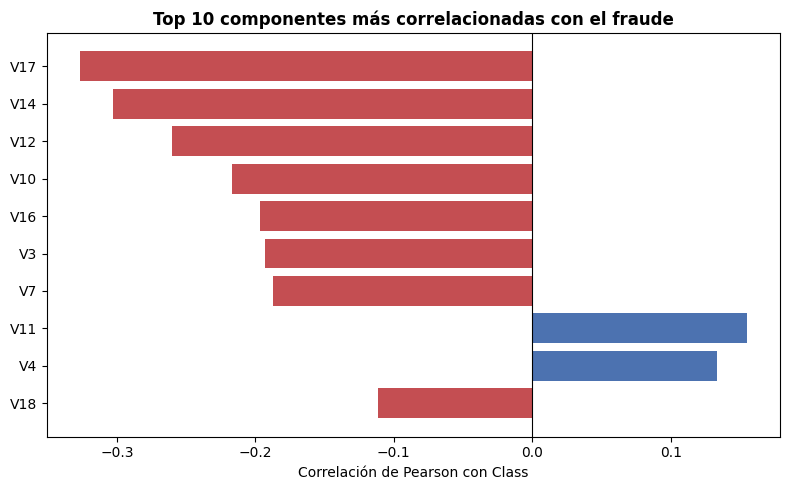

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

v_columns = [f"V{i}" for i in range(1, 29)]
corr_exprs = [F.corr("Class", c).alias(c) for c in v_columns]

# Un único barrido distribuido para las 28 correlaciones de Pearson
corr_dict = df.select(*corr_exprs).collect()[0].asDict()

corr_df = (
    pd.DataFrame(list(corr_dict.items()), columns=["Caracteristica", "Correlacion"])
    .assign(Impacto_Absoluto=lambda d: d["Correlacion"].abs())
    .sort_values("Impacto_Absoluto", ascending=False)
    .reset_index(drop=True)
)

top10 = corr_df.head(10)
print("Top 10 variables más correlacionadas con el fraude:")
print(top10[["Caracteristica", "Correlacion"]].to_string(index=False))

# Visualización (se invierte el orden para que la mayor quede arriba)
top10_plot = top10.iloc[::-1]
colores = ["#C44E52" if v < 0 else "#4C72B0" for v in top10_plot["Correlacion"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10_plot["Caracteristica"], top10_plot["Correlacion"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con Class")
ax.set_title("Top 10 componentes más correlacionadas con el fraude", fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura de los resultados**

- `V17` (r = −0.33), `V14` (−0.30) y `V12` (−0.26) son las componentes con mayor asociación lineal con el fraude. `V11` (+0.15) y `V4` (+0.13) son las positivas más fuertes.
- Las magnitudes son moderadas (|r| ≤ 0.33). La correlación de Pearson con una variable binaria muy desbalanceada solo mide asociación lineal y puede subestimar señales no lineales: es una guía de exploración, no un criterio único de selección de variables.
- **Hipótesis de ingeniería a validar:** en un sistema con restricciones de latencia de inferencia podría evaluarse reducir dimensionalidad conservando las variables más informativas. Esa decisión debería apoyarse en la importancia de variables del modelo entrenado, y no solo en la correlación lineal.

## 5. Perfil estadístico por clase

Se comparan `Amount` y `Time` segmentando por la variable objetivo, con una sola agregación agrupada por `Class`.

In [8]:
perfil = (
    df.groupBy("Class").agg(
        F.count("*").alias("Transacciones"),
        F.round(F.mean("Amount"), 2).alias("Monto_Promedio"),
        F.round(F.stddev("Amount"), 2).alias("Monto_Desviacion"),
        F.round(F.min("Amount"), 2).alias("Monto_Minimo"),
        F.round(F.median("Amount"), 2).alias("Monto_Mediana"),
        F.round(F.max("Amount"), 2).alias("Monto_Maximo"),
        F.round(F.mean("Time"), 2).alias("Tiempo_Promedio"),
        F.round(F.stddev("Time"), 2).alias("Tiempo_Desviacion"),
    )
    .orderBy("Class")
)

# Transpuesto para leer ambas clases cara a cara
perfil.toPandas().set_index("Class").T

Class,0,1
Transacciones,284315.00,492.00
Monto_Promedio,88.29,122.21
Monto_Desviacion,250.11,256.68
Monto_Minimo,0.00,0.00
Monto_Mediana,22.00,9.25
Monto_Maximo,25691.16,2125.87
Tiempo_Promedio,94838.20,80746.81
Tiempo_Desviacion,47484.02,47835.37


| Métrica | Legítima (0) | Fraude (1) |
|---|---:|---:|
| Monto promedio | 88.29 | 122.21 |
| Monto mediana | 22.00 | 9.25 |
| Desviación estándar del monto | 250.11 | 256.68 |
| Monto máximo | 25,691.16 | 2,125.87 |
| Tiempo promedio (segundos desde la primera transacción) | 94,838.20 | 80,746.81 |

**Lectura de los resultados**

- A primera vista, el monto promedio del fraude (122.21) es mayor que el de las legítimas (88.29). Pero, la mediana es menos de la mitad (9.25 vs 22.00): el promedio está arrastrado por unos pocos fraudes de monto alto (el máximo es 2,125.87) y la mayoría de los fraudes son de montos muy bajos.
- Este patrón es coherente con la hipótesis de que los atacantes prueban si una tarjeta está activa con compras pequeñas antes de intentar montos mayores (*card testing*). El dataset no permite confirmarla: se plantea como hipótesis, no como conclusión.
- El tiempo promedio no es directamente interpretable: `Time` mide segundos desde la primera transacción de la ventana de dos días, no una hora del día. Se transforma en la siguiente sección.

## 6. Ingeniería de características: hora del día

`Time` es un contador lineal de segundos desde la primera transacción del dataset. Un modelo no puede inferir que el segundo 86,400 corresponde a la misma hora del día que el segundo 0. Se extrae entonces la **hora del día (0–23)** con `(Time / 3600) % 24` y se evalúa si la tasa de fraude cambia de forma marcada según la franja horaria.

Dos precisiones metodológicas:

- **Supuesto de alineación.** La documentación no indica a qué hora ocurrió la primera transacción; se asume que `Time = 0` coincide con la medianoche. El patrón de volumen que se observa a continuación (mínimo entre las 2 y las 5 AM, meseta diurna) es coherente con un ciclo día/noche, lo que respalda el supuesto de forma indirecta. Los resultados deben leerse como un patrón relativo.
- **Extracción vs. codificación cíclica.** `Hour` es una extracción de la hora del día, adecuada para modelos de árboles. Para modelos lineales o redes neuronales, donde las 23 h y las 0 h deben ser "vecinas", correspondería además una codificación cíclica (`sin`/`cos`).

In [9]:
# Hora del día (0-23). Se trunca a entero y el módulo 24 reinicia el ciclo en el segundo día
df_eda = df.withColumn("Hour", (F.col("Time") / 3600).cast("integer") % 24)

hourly_analysis = (
    df_eda.groupBy("Hour").agg(
        F.count("*").alias("Total_Tx"),
        F.sum("Class").alias("Total_Fraudes"),  # Class es 0/1: la suma es el nº de fraudes
    )
    .withColumn("Tasa_Fraude_Pct", F.round(F.col("Total_Fraudes") / F.col("Total_Tx") * 100, 3))
    .orderBy("Hour")
)

hourly_analysis.show(24)

+----+--------+-------------+---------------+
|Hour|Total_Tx|Total_Fraudes|Tasa_Fraude_Pct|
+----+--------+-------------+---------------+
|   0|    7695|            6|          0.078|
|   1|    4220|           10|          0.237|
|   2|    3328|           57|          1.713|
|   3|    3492|           17|          0.487|
|   4|    2209|           23|          1.041|
|   5|    2990|           11|          0.368|
|   6|    4101|            9|          0.219|
|   7|    7243|           23|          0.318|
|   8|   10276|            9|          0.088|
|   9|   15838|           16|          0.101|
|  10|   16598|            8|          0.048|
|  11|   16856|           53|          0.314|
|  12|   15420|           17|           0.11|
|  13|   15365|           17|          0.111|
|  14|   16570|           23|          0.139|
|  15|   16461|           26|          0.158|
|  16|   16453|           22|          0.134|
|  17|   16166|           29|          0.179|
|  18|   17039|           33|     

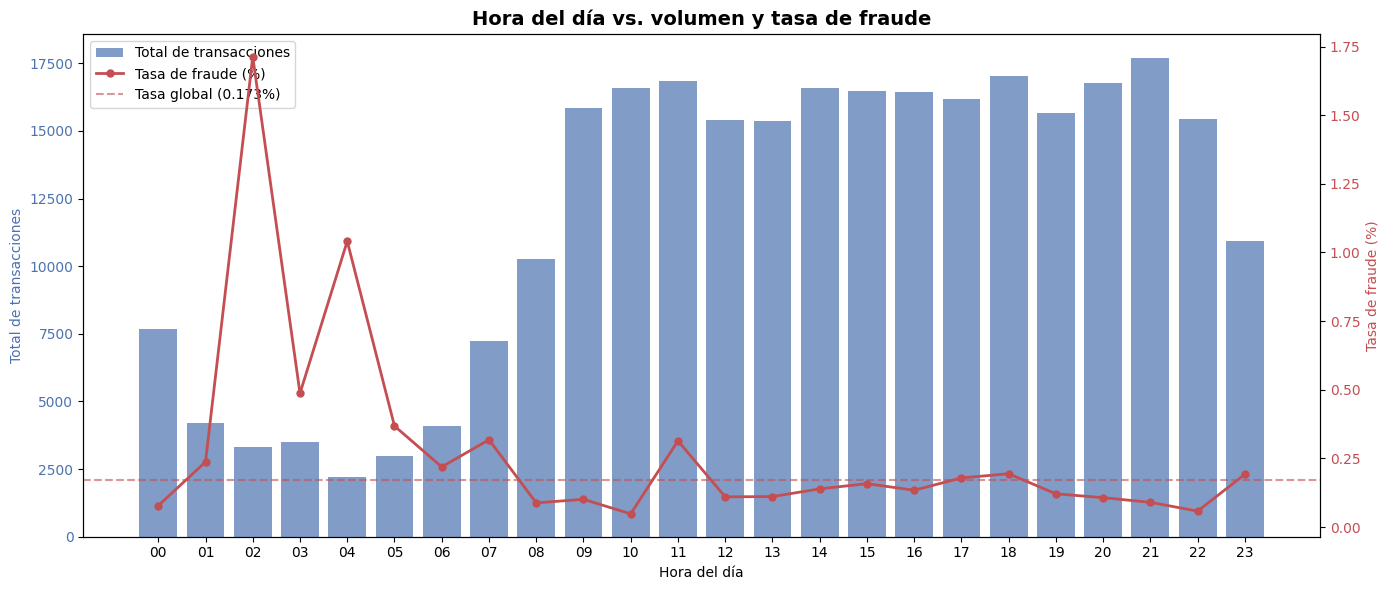

In [10]:
import matplotlib.pyplot as plt

h = hourly_analysis.toPandas()
overall_rate = h["Total_Fraudes"].sum() / h["Total_Tx"].sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: volumen de transacciones por hora
ax1.bar(h["Hour"], h["Total_Tx"], color="#4C72B0", alpha=0.7, label="Total de transacciones")
ax1.set_xlabel("Hora del día")
ax1.set_ylabel("Total de transacciones", color="#4C72B0")
ax1.set_xticks(range(24))
ax1.set_xticklabels([f"{x:02d}" for x in range(24)])
ax1.tick_params(axis="y", labelcolor="#4C72B0")

# Línea: tasa de fraude (segundo eje) y referencia de la tasa global
ax2 = ax1.twinx()
ax2.plot(h["Hour"], h["Tasa_Fraude_Pct"], color="#C44E52", marker="o", linewidth=2,
         markersize=5, label="Tasa de fraude (%)")
ax2.axhline(overall_rate, color="#C44E52", linestyle="--", alpha=0.6,
            label=f"Tasa global ({overall_rate:.3f}%)")
ax2.set_ylabel("Tasa de fraude (%)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

plt.title("Hora del día vs. volumen y tasa de fraude", fontsize=14, fontweight="bold")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

**Lectura de los resultados**

- A las **2 AM** hay 57 fraudes sobre 3,328 transacciones: una tasa de **1.713%**, unas 10 veces la tasa global (0.173%). A las **4 AM** la tasa es de **1.041%** (23 fraudes sobre 2,209), unas 6 veces la global.
- Entre la 1 y las 5 AM todas las franjas superan la tasa global (entre 0.24% y 1.71%).
- Conviene distinguir **conteo** de **tasa**: a las 11 AM hay 53 fraudes (el segundo mayor conteo absoluto), pero con un volumen de 16,856 transacciones la tasa es de solo 0.314%. De madrugada ocurre lo contrario: pocos fraudes en términos absolutos, pero sobre un volumen muy bajo.
- **Cautela:** la muestra abarca solo dos días. El patrón podría reflejar episodios de ataque puntuales y no una estacionalidad estable; debería validarse con un historial más largo.

`Hour` queda como característica candidata para el modelo.

## 7. Análisis bivariado: `V14` vs `V17`

Las dos componentes con mayor correlación negativa con el fraude son `V17` y `V14`. Un diagrama de dispersión coloreado por clase permite evaluar la **complejidad del problema**:

- Si los fraudes formaran una "isla" separada de las transacciones legítimas, el problema sería casi linealmente separable y un modelo simple (regresión logística) podría bastar.
- Si aparecen mezclados o rodeados por transacciones normales, se necesitan modelos no lineales capaces de trazar fronteras de decisión irregulares.

Para poder graficar sin saturar la memoria del driver, se conserva el 100% de los fraudes y se toma una **muestra del 5% de las legítimas** (solo con fines de visualización).

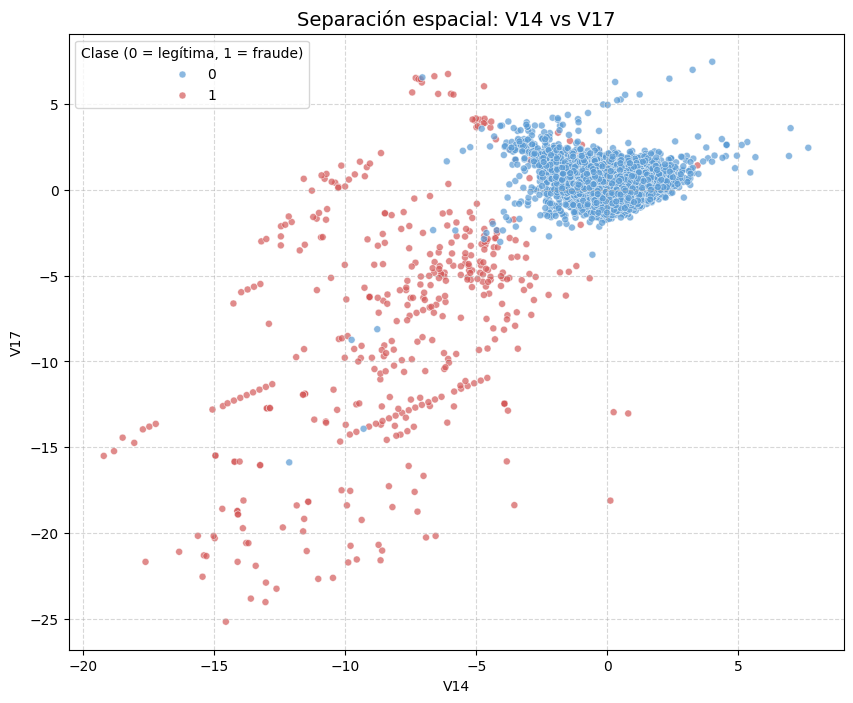

In [11]:
import seaborn as sns

vars_interest = ["V14", "V17", "Class"]
frauds = df.filter(F.col("Class") == 1).select(*vars_interest)
legitimas = df.filter(F.col("Class") == 0).select(*vars_interest)

# Submuestreo solo para visualizar (la densidad relativa entre clases no es comparable)
legitimate_sample = legitimas.sample(withReplacement=False, fraction=0.05, seed=42)
plot_df = frauds.union(legitimate_sample).toPandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df, x="V14", y="V17", hue="Class",
    palette={0: "#5A9BD4", 1: "#D45A5A"}, alpha=0.7, s=25,
)
plt.title("Separación espacial: V14 vs V17", fontsize=14)
plt.xlabel("V14")
plt.ylabel("V17")
plt.legend(title="Clase (0 = legítima, 1 = fraude)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Lectura del gráfico**

- Las transacciones legítimas (azul) forman una nube densa alrededor del origen: en estas componentes su dispersión es baja.
- Los fraudes (rojo) no se distribuyen al azar: se desplazan hacia el **cuadrante inferior izquierdo**, con valores negativos de `V14` y `V17`.
- Hay solapamiento parcial entre clases, por lo que **una recta no separa el problema por completo**.

**Implicancia para la elección del modelo.** Los árboles de decisión particionan el espacio con cortes ortogonales y pueden combinar reglas del tipo "`V14` < a y `V17` < b" para aislar la región donde se concentran los fraudes. Por eso se priorizan los ensambles de árboles (Random Forest, gradient boosting) por sobre los modelos lineales. Se trata de una hipótesis derivada de solo dos variables; contrastarla contra un baseline lineal queda como próximo paso.

## 8. Escalamiento de `Amount` y `Time`

`V1`–`V28` ya vienen en una escala comparable (salida de PCA), pero `Amount` (0 a 25,691, con cola pesada) y `Time` (0 a ~172,000 segundos) no. Los métodos basados en distancias (k-NN, SMOTE) y los modelos lineales son sensibles a la escala, y el análisis de la sección 9 usa distancia euclídea, así que conviene normalizarlas.

- **`Amount`:** primero `log1p(x) = ln(1 + x)`, que comprime la cola derecha y está definida en `x = 0`; luego `RobustScaler`.
- **`Time`:** `RobustScaler`.
- **Por qué `RobustScaler`:** centra con la **mediana** y escala con el **IQR**, estadísticos poco afectados por valores extremos. `StandardScaler` (media y desviación) se distorsionaría justamente por los atípicos que se decidió conservar.
- En Spark, `RobustScaler` **no centra por defecto** (`withCentering=False`); aquí se activa para obtener el comportamiento clásico (mediana → 0, IQR → 1).

> **Nota metodológica.** Con fines exploratorios el escalador se ajusta sobre todo el dataset. En el pipeline productivo se ajustará **solo con el conjunto de entrenamiento** y se aplicará luego a validación/test, para evitar fuga de información (*data leakage*).

In [12]:
from pyspark.ml.feature import VectorAssembler, RobustScaler
from pyspark.ml.functions import vector_to_array


def robust_scaling(dataframe, columna, salida):
    """Aplica RobustScaler (mediana e IQR) a una columna numérica y devuelve un escalar."""
    vec, vec_esc = f"{columna}_vec", f"{columna}_vec_esc"
    assembly = VectorAssembler(inputCols=[columna], outputCol=vec).transform(dataframe)
    scaler = RobustScaler(inputCol=vec, outputCol=vec_esc, withCentering=True, withScaling=True)
    scaling = scaler.fit(assembly).transform(assembly)
    return (
        scaling
        .withColumn(salida, vector_to_array(F.col(vec_esc))[0])
        .drop(vec, vec_esc)
    )


# Amount: log1p para comprimir la cola derecha (log1p(0) = 0) y luego scaling robusto
df_prep = df_eda.withColumn("Amount_log", F.log1p("Amount"))
df_prep = robust_scaling(df_prep, "Amount_log", "Amount_scaled")
df_prep = robust_scaling(df_prep, "Time", "Time_scaled")
df_prep = df_prep.drop("Amount", "Amount_log", "Time")

FEATURE_COLS = [f"V{i}" for i in range(1, 29)] + ["Amount_scaled", "Time_scaled"]
print(f"Columnas del dataset preprocesado: {df_prep.columns}")

Columnas del dataset preprocesado: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour', 'Amount_scaled', 'Time_scaled']


In [13]:
# Verificación: tras el escalado robusto la mediana debe ser ≈ 0 y el IQR ≈ 1
for c in ["Amount_scaled", "Time_scaled"]:
    q1, median, q3 = df_prep.approxQuantile(c, [0.25, 0.5, 0.75], 0.001)
    print(f"{c}: median = {median:.3f} | IQR = {q3 - q1:.3f}")

Amount_scaled: median = 0.000 | IQR = 1.000
Time_scaled: median = 0.000 | IQR = 1.000


## 9. Estrategia frente al desbalance de clases

Con 492 fraudes frente a 284,315 transacciones legítimas, un modelo entrenado sin corrección tiende a ignorar la clase minoritaria. Se consideran tres estrategias:

- **Undersampling:** elimina transacciones legítimas hasta igualar la cantidad de fraudes. Entrena muy rápido, pero descarta más del 99% del comportamiento normal observado. Se descarta como estrategia principal, aunque se incluye como referencia en la comparación empírica (sección 10).
- **SMOTE (sobremuestreo sintético):** genera fraudes "nuevos" interpolando entre fraudes reales vecinos. Depende de que las distancias entre puntos sean informativas; en espacios de muy alta dimensionalidad esto se degrada y puede introducir ruido y sobreajuste.
- **Cost-Sensitive Learning:** no altera los datos; modifica la función de pérdida del modelo para penalizar más los errores sobre la clase minoritaria. En una arquitectura Big Data evita generar y mover datos sintéticos por la red.

### 9.1 Viabilidad de SMOTE: ¿siguen siendo informativas las distancias?

SMOTE se apoya en vecinos más cercanos, por lo que necesita que las distancias distingan entre puntos cercanos y lejanos. En dimensionalidad muy alta ocurre la **concentración de distancias**: todos los pares de puntos quedan a distancias casi iguales y la noción de "vecino cercano" pierde sentido.

Para cuantificarlo se calcula el **ratio de concentración de distancias** (distancia máxima / distancia mínima entre pares de puntos):

| Resultado | Interpretación |
|---|---|
| **Ratio ≈ 1** (p. ej. 1.01–1.05) | Alta concentración: las distancias no discriminan; k-NN y SMOTE se degradan |
| **Ratio >> 1** (p. ej. 5, 20, 100+) | Baja concentración: las distancias siguen siendo útiles |

**Enfoque de cómputo (patrón híbrido para Glue/EMR):** muestreo distribuido en Spark, traslado de una muestra acotada al driver y cálculo matricial con NumPy/scikit-learn, cuyas rutinas están optimizadas en C.

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

# 1. muestra distribuida de la clase mayoritaria (semilla fija: reproducible)
sample = (
    df_prep.filter(F.col("Class") == 0)
    .sample(withReplacement=False, fraction=0.02, seed=42)
    .limit(5000)  # tope estricto para controlar la memoria del driver
)

# 2. Se trae al driver y se calcula la matriz de distancias euclídeas
X_sample = sample.select(*FEATURE_COLS).toPandas().values
print(f"Calculando matriz de distancias para {X_sample.shape[0]:,} registros...")
D = pairwise_distances(X_sample, metric="euclidean")

# 3. Triángulo superior: cada par de puntos una sola vez y sin la diagonal
#    (la distancia de un punto a sí mismo es 0 y no aporta información)
pair_distance = D[np.triu_indices_from(D, k=1)]
postive_distance = pair_distance[pair_distance > 0]  # se excluyen duplicados exactos (evita dividir por 0)

max_dist, min_dist = postive_distance.max(), postive_distance.min()
print(f"Distancia máxima: {max_dist:.4f}")
print(f"Distancia mínima: {min_dist:.4f}")
print(f"Ratio max/min:    {max_dist / min_dist:,.2f}")

# 4. Pares únicos casi idénticos (distancia < 0.001)
n_near_duplicates = int((pair_distance < 0.001).sum())
print(f"Pares de transacciones casi idénticas (distancia < 0.001): {n_near_duplicates}")

Calculando matriz de distancias para 5,000 registros...
Distancia máxima: 83.0995
Distancia mínima: 0.0001
Ratio max/min:    1,179,059.06
Pares de transacciones casi idénticas (distancia < 0.001): 2


**Lectura de los resultados** (ejecución de referencia con la semilla fija)

- Distancia máxima ≈ 83.10, mínima ≈ 0.0001 y ratio ≈ 1.18 × 10⁶. Está lejísimos de 1, por lo que **no se observa concentración de distancias** según esta métrica.
- Este cociente, sin embargo, es muy sensible a la distancia mínima: proviene de un par de transacciones con valores casi idénticos en las 30 variables y por eso **sobreestima el contraste** real. Para no depender de un solo par, se complementa con métricas más robustas.
- Además, SMOTE interpola dentro de la clase **minoritaria**, no de la mayoritaria. Por eso se repite la medición sobre los 492 fraudes.

**Métricas robustas.** Cuando la dimensionalidad domina, las distancias entre pares se vuelven casi iguales: el **coeficiente de variación** (desviación estándar / media de las distancias) tiende a 0 y el cociente entre los percentiles 95 y 5 tiende a 1. Valores claramente alejados de esos límites indican que las distancias aún distinguen entre vecinos cercanos y lejanos, condición necesaria para que k-NN (y por lo tanto SMOTE) tenga sentido. Con 30 dimensiones se espera una concentración moderada; la concentración severa aparece típicamente con cientos o miles.

In [15]:
def distance_summary(X, name):
    """Estadísticos de la distribución de distancias euclídeas entre todos los pares únicos."""
    D_ = pairwise_distances(X, metric="euclidean")
    d = D_[np.triu_indices_from(D_, k=1)]
    p5, p95 = np.percentile(d, [5, 95])
    return {
        "Grupo": name,
        "Puntos": X.shape[0],
        "Distancia media": d.mean(),
        "Coef. de variación (std/media)": d.std() / d.mean(),
        "p95 / p5": p95 / p5,
    }


# La clase minoritaria completa es pequeña: cabe sin problema en el driver
X_frauds = df_prep.filter(F.col("Class") == 1).select(*FEATURE_COLS).toPandas().values

pd.DataFrame([
    distance_summary(X_sample, "Legítimas (muestra)"),
    distance_summary(X_frauds, "Fraudes (clase minoritaria completa)"),
]).round(3)

,Grupo,Puntos,Distancia media,Coef. de variación (std/media),p95 / p5
0,Legítimas (muestra),5000,7.151,0.586,3.091
1,Fraudes (clase minoritaria completa),492,24.908,0.631,7.352


### 9.2 SMOTE vs. Cost-Sensitive Learning en un entorno distribuido

Aunque SMOTE es geométricamente viable en este espacio, el pipeline está pensado para ejecutarse en clústeres de **AWS Glue con PySpark**, y allí pesan criterios operativos:

| Criterio | SMOTE | Cost-Sensitive Learning | Implicancia en AWS Glue / PySpark |
|:---|:---|:---|:---|
| **Mecanismo** | Genera filas sintéticas interpolando entre vecinos de la clase minoritaria. | No altera los datos; pondera la función de pérdida para penalizar más los errores sobre fraudes. | Cost-Sensitive evita inyectar datos artificiales en el ecosistema. |
| **Costo computacional** | Alto. Balancear 1:1 puede duplicar el tamaño del dataset (≈ 284 mil filas nuevas) y buscar vecinos en un entorno distribuido implica *shuffles* costosos. | Bajo. Mantiene el tamaño original (~145 MB). | Cost-Sensitive reduce tiempo de cómputo y costo de infraestructura. |
| **Soporte nativo en PySpark** | Ninguno: MLlib no incluye SMOTE; requiere una implementación propia o librerías de terceros. | Nativo: `weightCol` está disponible en varios de los principales clasificadores de MLlib (Random Forest, GBT, regresión logística). | Cost-Sensitive es más simple de mantener. |
| **Riesgo principal** | Puede generar fraudes poco realistas si interpola entre vecinos que cruzan la frontera de clase. | Aprende de la distribución real, pero puede sobreajustarse a los pocos fraudes al ponderarlos fuertemente (peso ≈ 578). | Ambos riesgos se controlan con validación. |

**Decisión: se adopta Cost-Sensitive Learning.** Se agrega una columna de pesos que asigna a cada fraude un peso igual al desbalance (`n_legítimas / n_fraudes`, ≈ 578:1 sobre el dataset completo; se recalcula sobre el conjunto de entrenamiento) y se entrega directamente al estimador mediante `weightCol`.

Esta decisión se sustenta en criterios arquitectónicos y operativos. Su efecto sobre el desempeño se verifica empíricamente en la sección siguiente.

## 10. Prueba empírica de estrategias

Se comparan tres estrategias con el **mismo modelo** (Random Forest de 50 árboles, `seed=42`) y el **mismo split 80/20**:

- **A) Baseline:** entrenamiento sin corregir el desbalance.
- **B) Cost-Sensitive:** pesos de clase mediante `weightCol`.
- **C) Undersampling:** submuestreo de la clase mayoritaria hasta igualar la cantidad de fraudes.

**Métrica: AUPRC** (área bajo la curva Precision-Recall). Con 0.17% de positivos, la exactitud es engañosa y el ROC-AUC se ve inflado por la enorme cantidad de verdaderos negativos. En cambio, el AUPRC de un clasificador aleatorio equivale a la prevalencia de la clase positiva (≈ 0.0017), de modo que cualquier mejora es informativa.

**Regla de evaluación:** los pesos y el undersampling se aplican **solo al entrenamiento**; el conjunto de test conserva siempre la distribución real.

`Hour` se incluye como característica adicional (sin escalar, ya que los árboles no lo requieren).

In [17]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler

FEATURES_MODEL = FEATURE_COLS + ["Hour"]

def evaluate_strategies(df_preprocessing, feature_cols, seed=42):
    """
    Compara tres estrategias frente al desbalance con el mismo modelo y el mismo split:
      A) Baseline sin balancear
      B) Cost-Sensitive Learning (pesos de clase vía weightCol)
      C) Undersampling de la clase mayoritaria

    Devuelve (DataFrame de pandas con el AUPRC por estrategia, dict de models entrenados).
    """
    # 1. Ensamblar las características en un único vector (requisito de Spark ML)
    assembly = VectorAssembler(inputCols=feature_cols, outputCol="features")
    data = assembly.transform(df_preprocessing).select("features", "Class")

    # 2. Split 80/20. El test conserva la distribución real y no se modifica
    train, test = data.randomSplit([0.8, 0.2], seed=seed)
    train.cache()
    test.cache()

    n_frauds = train.filter(F.col("Class") == 1).count()
    n_legit = train.count() - n_frauds
    weight_fraud = n_legit / n_frauds
    prevalence = test.filter(F.col("Class") == 1).count() / test.count()
    print(f"Train: {n_legit:,} legítimas | {n_frauds:,} fraudes | peso de la clase minoritaria = {weight_fraud:.1f}")
    print(f"AUPRC de un clasificador aleatorio (prevalence en test) ≈ {prevalence:.4f}\n")

    # 3. Conjunto de entrenamiento de cada estrategia
    train_weight = train.withColumn(
        "class_weight", F.when(F.col("Class") == 1, weight_fraud).otherwise(1.0)
    )
    train_under = train.sampleBy("Class", fractions={0: n_frauds / n_legit, 1: 1.0}, seed=seed)

    strategies = {
        "A) Baseline (sin balancear)": (train, None),
        "B) Cost-Sensitive (weightCol)": (train_weight, "class_weight"),
        "C) Undersampling": (train_under, None),
    }

    evaluador = BinaryClassificationEvaluator(labelCol="Class", metricName="areaUnderPR")
    filas, models = [], {}

    for name, (data_train, col_weight) in strategies.items():
        params = dict(featuresCol="features", labelCol="Class", numTrees=50, seed=seed)
        if col_weight:
            params["weightCol"] = col_weight

        modelo = RandomForestClassifier(**params).fit(data_train)
        auprc = evaluador.evaluate(modelo.transform(test))

        models[name] = modelo
        filas.append({
            "Estrategia": name,
            "Filas de entrenamiento": data_train.count(),
            "AUPRC": round(auprc, 4),
        })
        print(f"{name}: AUPRC = {auprc:.4f}")

    train.unpersist()
    test.unpersist()
    return pd.DataFrame(filas), models

In [19]:
results, models = evaluate_strategies(df_prep, FEATURES_MODEL)
results

Train: 227,837 legítimas | 388 fraudes | peso de la clase minoritaria = 587.2
AUPRC de un clasificador aleatorio (prevalence en test) ≈ 0.0018

A) Baseline (sin balancear): AUPRC = 0.8674
B) Cost-Sensitive (weightCol): AUPRC = 0.8096
C) Undersampling: AUPRC = 0.7512


,Estrategia,Filas de entrenamiento,AUPRC
0,A) Baseline (sin balancear),228225,0.8674
1,B) Cost-Sensitive (weightCol),228225,0.8096
2,C) Undersampling,766,0.7512



- El conjunto de test contiene alrededor de 100 fraudes (el 20% de 492), por lo que el AUPRC es **sensible al split**. Diferencias pequeñas entre estrategias no son concluyentes sin repetir la comparación con validación cruzada estratificada.
- Ponderar las clases modifica el equilibrio entre *precision* y *recall* y las probabilidades que entrega el modelo; no garantiza por sí solo un mayor AUPRC. La elección del umbral de decisión debe basarse en el costo de negocio de un falso negativo (fraude no detectado) frente a un falso positivo (cliente legítimo bloqueado).
- Los hiperparámetros del Random Forest no fueron ajustados: el objetivo es comparar estrategias en igualdad de condiciones, no maximizar la métrica.
---
La elección de Cost-Sensitive se sostiene por criterios de arquitectura (sección 9), independientemente del resultado de esta comparación. Empíricamente, en este split el baseline obtuvo mayor AUPRC, lo cual es consistente con que Random Forest ya captura parte del desbalance por bootstrap y con que un peso tan agresivo (≈578:1) puede distorsionar el ranking de probabilidades. Esto no invalida la decisión de infraestructura, pero sí indica que el peso de clase debería ajustarse (no usar el ratio completo) y validarse con más de un split antes de llevarlo a producción.

## 11. Conclusiones y próximos pasos

### Conclusiones del análisis exploratorio

- **Calidad:** sin valores nulos; desbalance extremo (0.173% de fraudes).
- **Montos:** los valores atípicos de `Amount` se conservan como señal potencial. Los fraudes se concentran en montos bajos (mediana 9.25 vs 22.00), aunque con una mayor proporción en el tramo alto que las legítimas (18.9% vs 11.5%).
- **Tiempo:** la tasa de fraude aumenta de madrugada (picos a las 2 y 4 AM), por lo que `Hour` es una característica candidata.
- **Señal en las componentes:** `V17`, `V14` y `V12` son las más asociadas con el fraude; `V14` vs `V17` separa parcialmente las clases sin ser linealmente separables, lo que favorece a los ensambles de árboles.
- **Desbalance:** se adopta Cost-Sensitive Learning (`weightCol`) por costo computacional, soporte nativo en PySpark y simplicidad de mantenimiento en AWS Glue, y se compara empíricamente con un baseline y con undersampling usando AUPRC.

### Limitaciones y próximos pasos

1. **Evitar fuga de información:** dividir en train/test *antes* de ajustar el escalador y calcular los pesos, e integrar todo en un `Pipeline` de Spark ML reproducible.
2. **Validación más robusta:** validación cruzada estratificada y ajuste de hiperparámetros (`numTrees`, `maxDepth`), dado que el test contiene pocos fraudes.
3. **Baseline lineal:** comparar contra regresión logística para respaldar la elección de modelos de árboles.
4. **Selección de variables:** evaluar la importancia de variables del modelo y decidir si `Time_scaled` y `Hour` son redundantes.
5. **Umbral y calibración:** fijar el umbral de decisión según el costo de negocio y, si se necesitan probabilidades, recalibrarlas (los pesos de clase las desplazan).
6. **Validez temporal:** el dataset cubre solo dos días; los patrones horarios y la deriva de los datos deberían monitorearse con un historial mayor.
7. **Despliegue:** portar la lectura a S3 con `GlueContext` y empaquetar el preprocesamiento como job de AWS Glue.